In [1]:
import xarray as xr 
import numpy as np 
from pathlib import Path
from dask.distributed import Client
import sys, os

import pandas as pd

In [2]:
client = Client(
    n_workers=8,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 8
Total threads: 8,Total memory: 9.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40317,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33843,Total threads: 1
Dashboard: /proxy/45711/status,Memory: 1.12 GiB
Nanny: tcp://127.0.0.1:43671,


In [3]:
cf_threshold = 10

In [4]:
def open_files(root_path, preprocess=None):
    files = [f for f in root_path.glob('*.nc')]

    return xr.open_mfdataset(
        files,
        preprocess = preprocess,
        concat_dim='year',
        combine='nested',
        parallel=True,
        chunks='auto'
    )

In [5]:
folder_out = Path("/home/563/fm6730/localrepo/GC26-combined-solar-wind/data/processed/hour_capacity_factor_lower_than/daytime_only/merged_out/")
os.makedirs(folder_out, exist_ok=True)

In [6]:
him_path = Path(f"/home/563/fm6730/localrepo/GC26-combined-solar-wind/data/processed/hour_capacity_factor_lower_than/daytime_only/")
him_files = [f for f in him_path.glob(f'*_{cf_threshold}pc_*.nc')]

def preprocess(ds):
    return ds

him_ds = open_files(him_path, preprocess=preprocess)


2026-06-17 17:08:25,977 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 808.46 MiB -- Worker memory limit: 1.12 GiB
2026-06-17 17:08:28,795 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 810.34 MiB -- Worker memory limit: 1.12 GiB
2026-06-17 17:08:28,805 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. 

In [8]:
ds_total = xr.open_dataset(f"{him_path}/merged_out/daytime_hour_capacity_factor_lower_than_10pc_1940-2023.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/home/563/fm6730/localrepo/GC26-combined-solar-wind/data/processed/hour_capacity_factor_lower_than/daytime_only/merged_out/daytime_hour_capacity_factor_lower_than_10pc_1940-2023.nc'

In [ ]:
da_total = ds_total['percentage']

In [9]:
da = him_ds['percentage']

In [10]:
check = (da.sel(year=2005) - da.sel(year=2003))

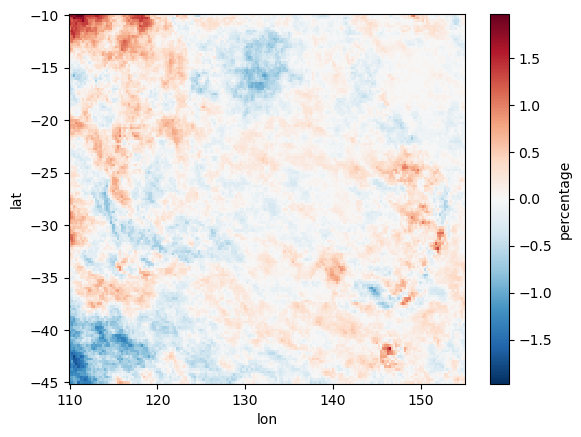

In [11]:
check.plot()

In [12]:
da_sorted = da.sortby('year')

# Group into 10-year bins and average
bins = list(np.arange(1940, 2021, 10)) + [2024]  # ensures 2020-2023 bin is captured
da_decadal = da_sorted.groupby_bins('year', bins, right=False).mean(dim='year')

In [13]:
da_decadal

<xarray.DataArray 'percentage' (year_bins: 9, lat: 141, lon: 181)> Size: 2MB
dask.array<transpose, shape=(9, 141, 181), dtype=float64, chunksize=(1, 141, 181), chunktype=numpy.ndarray>
Coordinates:
  * year_bins  (year_bins) interval[int64, left] 144B [1940, 1950) ... [2020,...
  * lat        (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * lon        (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0

In [14]:
da_sub = da_decadal.isel(year_bins=0) - da_decadal.isel(year_bins=2) 

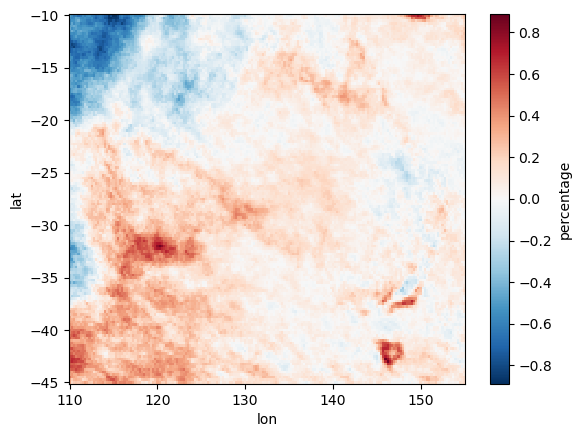

In [15]:
da_sub.plot()

In [16]:
da_mean = da_total

NameError: name 'da_total' is not defined

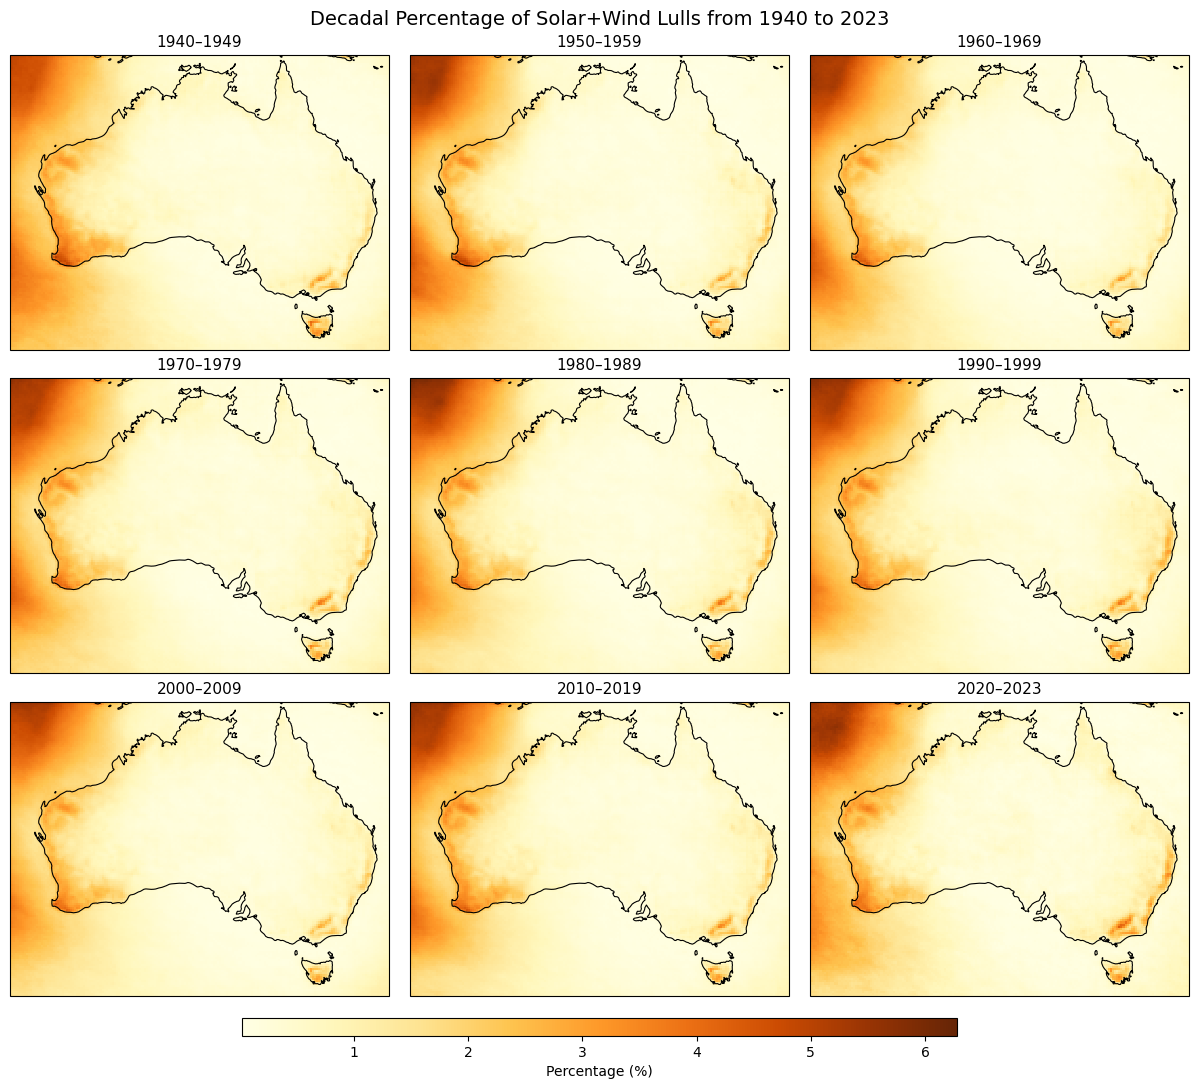

NameError: name 'da_mean' is not defined

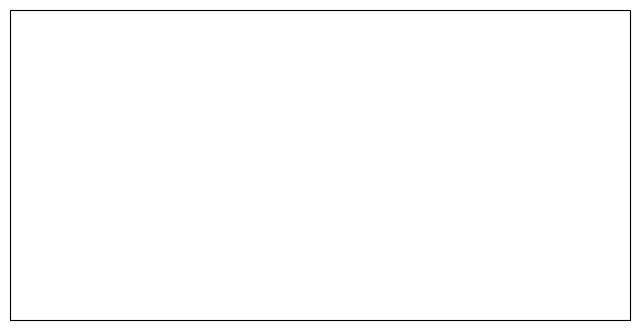

In [17]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

# -------------------------------------------------------
# Plot 1: Decadal maps (9 panels, one per decade)
# -------------------------------------------------------
da_decadal_loaded = da_decadal.compute()  # bring into memory (small enough)

n_panels = da_decadal_loaded.sizes['year_bins']
ncols = 3
nrows = -(-n_panels // ncols)  # ceil division

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3.5 * nrows),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)
axes = axes.flatten()

vmin, vmax = float(da_decadal_loaded.min()), float(da_decadal_loaded.max())

for i, year_bin in enumerate(da_decadal_loaded['year_bins'].values):
    ax = axes[i]
    da_decadal_loaded.isel(year_bins=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=sns.color_palette("YlOrBr", as_cmap=True),
        vmin=vmin, vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines(resolution='50m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(f"{year_bin.left}–{year_bin.right - 1}", fontsize=11)
    ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

# Hide any unused subplot axes
for j in range(n_panels, len(axes)):
    axes[j].axis('off')

# Shared colorbar
cbar = fig.colorbar(
    axes[0].collections[0], ax=axes, orientation='horizontal',
    shrink=0.6, pad=0.02, aspect=40
)
cbar.set_label('Percentage (%)')

fig.suptitle('Decadal Percentage of Solar+Wind Lulls from 1940 to 2023', fontsize=14, y=1.02)
plt.savefig('daytime_decadal_maps.png', dpi=150, bbox_inches='tight')
plt.show()


# -------------------------------------------------------
# Plot 2: Single overall mean map
# -------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

da_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=sns.color_palette("YlOrBr", as_cmap=True),
    cbar_kwargs={'label': 'Percentage (%)', 'shrink': 0.8}
)
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())
ax.set_title('Mean Percentage of Solar+Wind Lulls from 1940 to 2023', fontsize=13)

plt.savefig('daytime_mean_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
folder_fig = "/home/563/fm6730/localrepo/GC26-combined-solar-wind/figures/"

2026-06-17 17:13:26,044 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 833.20 MiB -- Worker memory limit: 1.12 GiB
2026-06-17 17:13:28,850 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 834.76 MiB -- Worker memory limit: 1.12 GiB
2026-06-17 17:13:28,891 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. 

In [22]:
os.makedirs(folder_fig, exist_ok=True)

In [23]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Load if dask-backed
da = da_sorted.compute()

fig, ax = plt.subplots(figsize=(8, 6))

# Initial frame
im = da.isel(year=0).plot(
    ax=ax,
    add_colorbar=True,
)

title = ax.set_title(f"Year: {int(da.year[0])}")


def update(frame):
    ax.clear()

    da.isel(year=frame).plot(
        ax=ax,
        add_colorbar=False,
        vmin=float(da.min()),
        vmax=float(da.max()),
    )

    ax.set_title(f"Year: {int(da.year[frame])}")

    return ax


ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(da.year),
    interval=300,   # ms per frame
)

ani.save(
    f"{folder_fig}percentage_animation.mp4",
    dpi=150,
    writer="ffmpeg",
)

plt.close()

print("Saved: percentage_animation.mp4")

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x900 -pix_fmt rgba -framerate 3.3333333333333335 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y percentage_animation.mp4


Saved: percentage_animation.mp4


In [20]:
!pwd

/home/563/fm6730/home
